### EDA of Multicoil Data

❌| Consistency of Slices, Coils, Length and Breadth <br>
✅| Created a DataSet according to fixed Coils, Length and Breadth <br>

#### Need to do

⬜️| Get more data <br>
⬜️| How to integrate all "diverse characteristic" data into a unified pool <br>


In [21]:
import sys 
import os 
import numpy as np
import pandas as pd
import fastmri
import sys
import importlib
from load_mri_data import file_loader, absolute_path_items, get_size, filter_coils, filter_shape, show_coils, rss_combine
from volume_sampler import vol_sampler, Individual_vol_sampler


In [ ]:
# !pip install requests

In [2]:
import fastmri

In [3]:
# Install necessary libraries
!pip install h5py scikit-image matplotlib requests

# Clone the fastMRI repo (from Meta)
!git clone https://github.com/facebookresearch/fastMRI.git

# Install PyTorch - make sure this matches your CUDA version if using GPU
!pip install torch torchvision

# Move into the repo
# %cd fastMRI


fatal: destination path 'fastMRI' already exists and is not an empty directory.


In [ ]:
# !mkdir -p data/brain_multicoil

In [ ]:
# !mkdir -p checkpoints/unet_brain_mc

In [ ]:
# !python /home/mahesh/health_ai_ons/Biswa_nil/fastMRI/fastmri_examples/unet/train_unet_demo.py\
#   --model unet \
#   --challenge multicoil \
#   --data-path /home/mahesh/health_ai_ons/Tauheed/MultiCoilData/multicoil_train\
#   --exp-dir ./checkpoints/unet_brain_mc \
#   --num-epochs 2 \
#   --batch-size 2

In [ ]:
# !pip install pip==23.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.2 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1

[notice] A new release of pip is available: 23.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# !pip uninstall pytorch-lightning -y
# !pip install pytorch-lightning==1.5.10

Requested pytorch-lightning==1.5.10 from https://files.pythonhosted.org/packages/18/f1/f59b307f75db1886c96e396eec878501510677394868680b8d2b8b58c47c/pytorch_lightning-1.5.10-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    torch (>=1.7.*)
           ~~~~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement pytorch-lightning==1.5.10 (from versions: 0.0.2, 0.2, 0.2.2, 0.2.3, 0.2.4, 0.2.4.1, 0.2.5, 0.2.5.1, 0.2.5.2, 0.2.6, 0.3, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.4.1, 0.3.5, 0.3.6, 0.3.6.1, 0.3.6.3, 0.3.6.4, 0.3.6.5, 0.3.6.6, 0.3.6.7, 0.3.6.8, 0.3.6.9, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.7, 0.4.8, 0.4.9, 0.5.0, 0.5.1, 0.5.1.2, 0.5.1.3, 0.5.2, 0.5.2.1, 0.5.3, 0.5.3.1, 0.5.3.2, 0.5.3.3, 0.6.0, 0.7.1, 0.7.3, 0.7.5, 0.7.6, 0.8.1, 0.8.3, 0.8.4, 0.8.5, 0.9.0, 0.10.0, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0, 1.1.1, 1.1.2, 1.1.3, 1.1.4, 1.1.5,

In [ ]:
# is_notebook = True   # IPYNB does not reload the previously imported packages and hence we need to reload to reflect changes without losing the variables 
# if is_notebook:
#     importlib.reload(sys.modules['load_mri_data'])  # Reloading the file to reflect changes
#     importlib.reload(sys.modules['volume_sampler'])
#     from load_mri_data import file_loader, absolute_path_items, get_size, filter_coils, filter_shape, show_coils
#     from volume_sampler import vol_sampler, Individual_vol_sampler

In [4]:
folder_path = "/home/biswamitra/health/knee_data/val/multicoil_val"
items = file_loader.get_file_items(folder_path)
file_paths = absolute_path_items(items, folder_path)
print("Number of files: ", len(items))
for i in range(0,len(items)):
    print(f"file number {i+1} :", items[i], file_paths[i]) 


file1000538.h5
Number of files:  198
file number 1 : file1000593.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1000593.h5
file number 2 : file1002067.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1002067.h5
file number 3 : file1001077.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1001077.h5
file number 4 : file1001566.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1001566.h5
file number 5 : file1001850.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1001850.h5
file number 6 : file1000196.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1000196.h5
file number 7 : file1000277.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1000277.h5
file number 8 : file1001818.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1001818.h5
file number 9 : file1001930.h5 /home/biswamitra/health/knee_data/val/multicoil_val/file1001930.h5
file number 10 : file1002436.h5 /home/biswamitra/health/knee_data/val/multicoil_v

In [ ]:
# fs_data = vol_sampler(folder_path).load_h5py() #too much unoptimal

file1000906.h5


In [12]:
#create own function for visualization
import h5py
import os
from collections import defaultdict
num_coils_map = defaultdict(int)
x_size_freq_map = defaultdict(int)
y_size_freq_map = defaultdict(int)

#we need to iterate through each file in the directory and process each one sequentially
dir_path = "/home/biswamitra/health/knee_data/val/multicoil_val"
all_files = os.listdir(dir_path)
print("number of files in the directory: ",len(all_files))

for file_name in all_files:
    curr_path = os.path.join(dir_path,file_name)
    #load h5 file and process
    with h5py.File(curr_path,'r') as hf:
        hf_data = hf['kspace'] #this holds all slices
        slices, coils, x_size, y_size = hf_data.shape
        num_coils_map[coils] += slices
        x_size_freq_map[x_size] += slices
        y_size_freq_map[y_size] += slices

number of files in the directory:  199


In [11]:
for k,v in num_coils_map.items():
    print(k,v)

15 7135


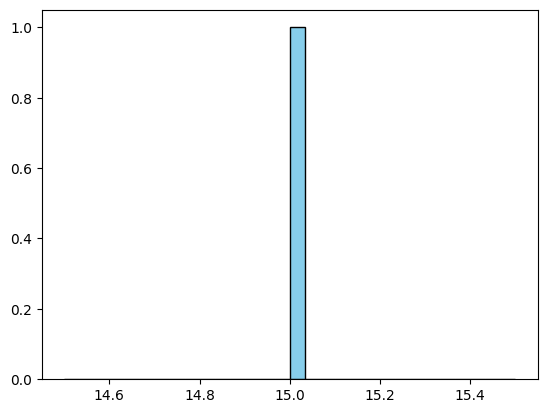

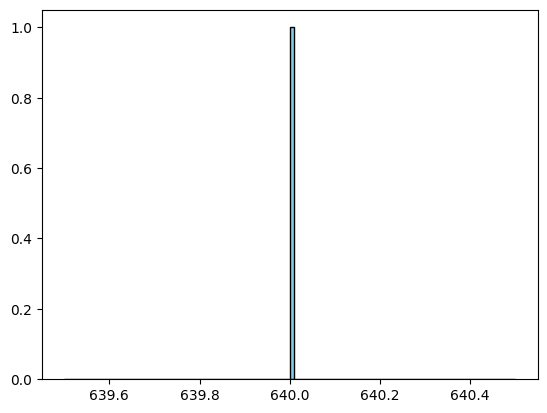

In [18]:
# print(len(fs_data)) 
coils,x_size,y_size = num_coils_map, x_size_freq_map, y_size_freq_map
import matplotlib.pyplot as plt
plt.hist(coils, bins=30, color='skyblue', edgecolor='black')
plt.show()
plt.hist(x_size, bins=100, color='skyblue', edgecolor='black')
plt.show()

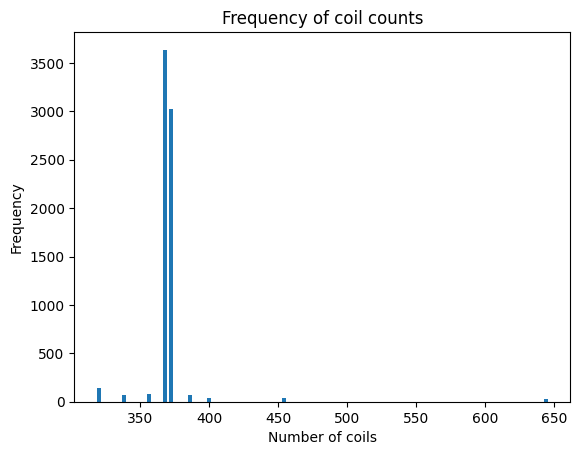

In [17]:
import matplotlib.pyplot as plt
plt.figure()
plt.bar(y_size_freq_map.keys(),y_size_freq_map.values(),width=3)
plt.xlabel("Number of coils")
plt.ylabel("Frequency")
plt.title("Frequency of coil counts")
plt.show()

#### Flitering according to Coils

In [ ]:
# print(coils)
# print(x_size)
# print(y_size)

[15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,

In [ ]:
# from collections import Counter

# # Count frequencies
# print("Unique frequencies for coils:")
# for value, count in Counter(coils).items():
#     print(f"Value: {value}, Frequency: {count}")

# print("\nUnique frequencies for x_size:")
# for value, count in Counter(x_size).items():
#     print(f"Value: {value}, Frequency: {count}")

# print("\nUnique frequencies for y_size:")
# for value, count in Counter(y_size).items():
#     print(f"Value: {value}, Frequency: {count}")


Unique frequencies for coils:
Value: 15, Frequency: 4056

Unique frequencies for x_size:
Value: 640, Frequency: 4056

Unique frequencies for y_size:
Value: 368, Frequency: 2018
Value: 372, Frequency: 1904
Value: 370, Frequency: 64
Value: 320, Frequency: 70


In [19]:
def print_frequencies(name, values):
    print(f"\n{name} frequencies:")
    for value, count in values.items():
        print(f"  {value}: {count}")

print_frequencies("Coils", num_coils_map)
print_frequencies("X Size", x_size_freq_map)
print_frequencies("Y Size", y_size_freq_map)



Coils frequencies:
  15: 7135

X Size frequencies:
  640: 7135

Y Size frequencies:
  368: 3636
  356: 84
  372: 3025
  386: 69
  320: 146
  338: 72
  454: 35
  644: 33
  400: 35


In [ ]:
# # Visualize samples from different y_size groups
# import matplotlib.pyplot as plt
# from fastmri.data import transforms as T

# # Get one sample from each y_size group
# samples_to_check = {}
# for i, (data, y) in enumerate(zip(fs_data, y_size)):
#     if y not in samples_to_check:
#         samples_to_check[y] = (data, i)
#     if len(samples_to_check) == 4:  # All 4 y_sizes
#         break

# # Visualize
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# for idx, (y_val, (data, i)) in enumerate(sorted(samples_to_check.items())):
#     # Debug: check data shape
#     print(f"y_size={y_val}, data shape: {data.shape}")
    
#     # Handle different data structures
#     if data.ndim == 4:  # (slices, coils, height, width)
#         slice_kspace = data[len(data)//2]  # Middle slice
#     elif data.ndim == 3:  # (coils, height, width) - already a single slice
#         slice_kspace = data
#     else:
#         print(f"Unexpected data shape: {data.shape}")
#         continue
    
#     slice_kspace_tensor = T.to_tensor(slice_kspace)
#     slice_image = fastmri.ifft2c(slice_kspace_tensor)
#     slice_image_abs = fastmri.complex_abs(slice_image)
    
#     print(f"slice_image_abs shape: {slice_image_abs.shape}")
    
#     # Show one coil (first coil)
#     axes[0, idx].imshow(slice_image_abs[0].numpy(), cmap='gray')
#     axes[0, idx].set_title(f'y_size={y_val} (idx {i})')
#     axes[0, idx].axis('off')
    
#     # Show with crop lines for 368
#     axes[1, idx].imshow(slice_image_abs[0].numpy(), cmap='gray')
#     if y_val > 368:
#         crop_amount = (y_val - 368) // 2
#         axes[1, idx].axvline(crop_amount, color='r', linestyle='--', linewidth=1)
#         axes[1, idx].axvline(y_val - crop_amount, color='r', linestyle='--', linewidth=1)
#     axes[1, idx].set_title(f'With crop to 368')
#     axes[1, idx].axis('off')

# plt.tight_layout()
# plt.show()

# Not doing the filtering as the data has same number of coils and is almost similar in dimensions too so we can do some padding to increase the dataset

In [ ]:
# fs_data_filtered = filter_coils(fs_data,15)
# print(len(fs_data_filtered))
# print(len(fs_data_filtered)/len(fs_data)*100)
# coils,x_size,y_size = get_size(fs_data_filtered)
# import matplotlib.pyplot as plt
# plt.hist(coils, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# plt.hist(x_size, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# plt.hist(y_size, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# print(np.unique(np.array(x_size)))
# print(np.unique(np.array(y_size)))

#### Flitering according to Shape

In [ ]:
# fs_data_Sh_filtered = filter_shape(fs_data_filtered,640,368)
# print(len(fs_data_Sh_filtered))
# print(len(fs_data_Sh_filtered)/len(fs_data_filtered)*100)
# coils,x_size,y_size = get_size(fs_data_Sh_filtered)
# import matplotlib.pyplot as plt
# plt.hist(coils, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# plt.hist(x_size, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# plt.hist(y_size, bins=30, color='skyblue', edgecolor='black')
# plt.show()
# print(np.unique(np.array(x_size)))
# print(np.unique(np.array(y_size)))

### Converting to nparray and saving

In [ ]:

# fs_coil_size_filtered = np.array(fs_data_Sh_filtered)
# print(fs_coil_size_filtered.shape)

(2018, 15, 640, 368)


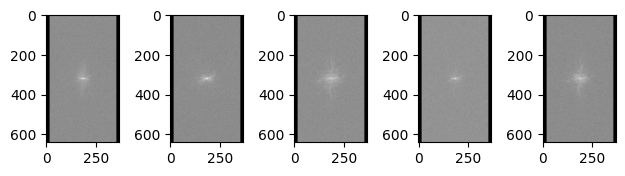

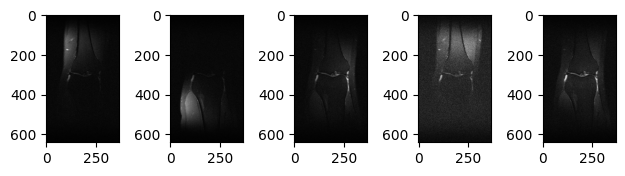

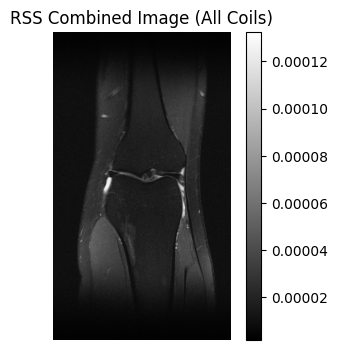

In [22]:
from fastmri.data import transforms as T
file_path = "/home/biswamitra/health/knee_data/val/multicoil_val/file1000000.h5"
with h5py.File(file_path,'r') as hf:
    slice_kspace = hf['kspace'][hf['kspace'].shape[0]//2]
l = [i for i in range(0,5,1)]
# for i in range(0,16,1):
slice_kspace2 = T.to_tensor(slice_kspace)      # Convert from numpy array to pytorch tensor
slice_image = fastmri.ifft2c(slice_kspace2)           # Apply Inverse Fourier Transform to get the complex image
slice_image_abs = fastmri.complex_abs(slice_image)

# RSS combine across coils (dim=0 is the coil dimension)
rss_image = fastmri.rss(slice_image_abs, dim=0)

# Visualize individual coils
show_coils(np.log(np.abs(slice_kspace) + 1e-9),l)
show_coils(slice_image_abs, l, cmap='gray')

# Visualize RSS combined image
plt.figure(figsize=(4, 4))
plt.imshow(rss_image.numpy(), cmap='gray')
plt.title('RSS Combined Image (All Coils)')
plt.axis('off')
plt.colorbar()
plt.show()

In [52]:
slice_kspace2.shape

torch.Size([15, 640, 368, 2])

In [12]:
file_name = f"coil{fs_coil_size_filtered.shape[1]}_size{fs_coil_size_filtered.shape[2]}_{fs_coil_size_filtered.shape[3]}"
save_path = os.path.join("/home/mahesh/health_ai_ons/data_ons/filtered_data",file_name)
print(save_path)

np.save(save_path, fs_coil_size_filtered)

/home/mahesh/health_ai_ons/data_ons/filtered_data/coil4_size640_320


# personal exploration

In [26]:
#imports
import h5py
import fastmri
from fastmri.data import transforms as T
import matplotlib.pyplot as plt

Total slices in volume: 35
Using slice 17
RSS min: 0.0000
RSS max: 0.0001


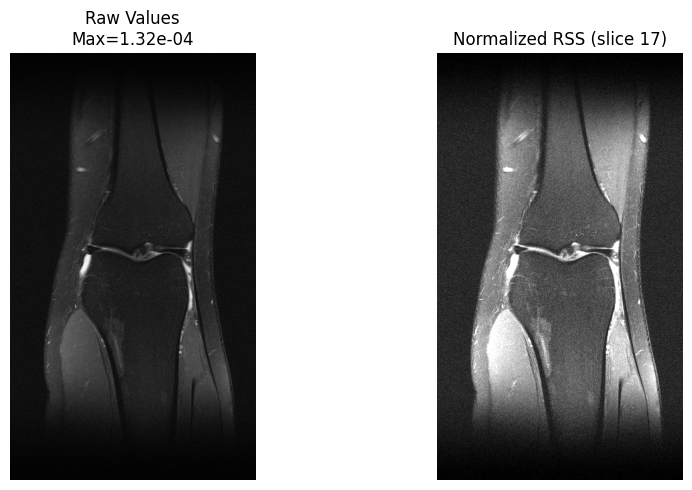

IndexError: index 2 is out of bounds for axis 0 with size 2

In [ ]:
#load data
file_path = "/home/biswamitra/health/knee_data/val/multicoil_val/file1000000.h5"
with h5py.File(file_path,'r') as hf:
    # Check how many slices
    print(f"Total slices in volume: {hf['kspace'].shape[0]}")
    # Use MIDDLE slice, not first (first is often empty/noise)
    middle_slice = hf['kspace'].shape[0] // 2
    print(f"Using slice {middle_slice}")
    k_space_data = hf['kspace'][middle_slice]
k_space_tensor = T.to_tensor(k_space_data)
ifft_data = fastmri.ifft2c(k_space_tensor)
abs_data = fastmri.complex_abs(ifft_data)

#do simple rss
rss_image_data = fastmri.rss(abs_data,dim=0)

# Check value range
print(f"RSS min: {rss_image_data.min():.4f}")
print(f"RSS max: {rss_image_data.max():.4f}")

# Visualize with proper normalization  
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Without normalization (will look bad if values are small)
axes[0].imshow(rss_image_data.numpy(), cmap='gray')
axes[0].set_title(f'Raw Values\nMax={rss_image_data.max():.2e}')
axes[0].axis('off')

# # With percentile normalization (CORRECT way)
# rss_norm = normalize_for_display(rss_image_data, method='percentile', p_low=1, p_high=99)
# axes[1].imshow(rss_norm, cmap='gray')
# axes[1].set_title(f'Normalized RSS (slice {middle_slice})')
# axes[1].axis('off')

plt.tight_layout()
plt.show()

### 🔑 Key Lesson: First/Last Slices Are Often Empty

In 3D MRI volumes:
- **Slice 0 and last slices** often contain NO anatomy, just noise
- **Middle slices** contain the actual anatomical structures
- Always use `volume.shape[0] // 2` to get a representative slice

That's why `fs_coil_size_filtered[100]` worked (it's from middle of dataset) but `hf['kspace'][0]` showed nothing!

In [49]:
with h5py.File(file_path,'r') as hf:
    k_space_data = hf['kspace'][0] #let's first work with the starting slice

In [42]:
#lets check the full data
i_space_data = fastmri.ifft2c(k_space_tensor)
print(i_space_data.shape)

torch.Size([15, 640, 368, 2])
